In [1]:
import sys
print(sys.executable)


c:\Users\thion\.conda\envs\learn-env\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


In [3]:
# Clear all dataframes and variables
%reset -f

# Re-import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

print("All variables cleared successfully")

c:\Users\thion\.conda\envs\learn-env\Lib\site-packages\requests\__init__.py:109: RequestsDependencyWarning: urllib3 (1.26.18) or chardet (6.0.0.post1)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


All variables cleared successfully


In [4]:
# Data Collection for Kenya Monetary Policy Project
# Goal: Load and explore macroeconomic and financial data

In [5]:
import pandas as pd
import os
import kagglehub

# 1. Download/Get path
path = kagglehub.dataset_download("macmini62/nairobi-securities-exchangense-stocks-data")
all_files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith('.csv')]

# 2. Loop and Combine
li = []
for filename in all_files:
    df_year = pd.read_csv(filename)
    
    # Standardize column names to handle 'CODE' vs 'code' vs 'Ticker'
    df_year.columns = [c.upper().strip() for c in df_year.columns]
    
    # Rename 'TICKER' to 'CODE' if that's what the newer files use
    if 'TICKER' in df_year.columns:
        df_year = df_year.rename(columns={'TICKER': 'CODE'})
        
    li.append(df_year)

nasi_cbr = pd.concat(li, axis=0, ignore_index=True)

# 3. Filter for the Index
# Note: In NSE data, the All Share Index is usually coded as 'NASI' or 'NSEASI'
# The 20-Share Index is 'NSE20'
nasi_data = nasi_cbr[nasi_cbr['CODE'].str.contains('NASI', case=False, na=False)].copy()

# 4. Sort by Date
nasi_data['DATE'] = pd.to_datetime(nasi_data['DATE'], format='mixed', dayfirst=True)
nasi_data = nasi_data.sort_values(by='DATE')

# Save the combined file
nasi_data.to_csv(r"C:\Users\thion\Kenya-Monetary-Policy-Stock-Market\notebooks\data\raw\nasi_2008_2025.csv", index=False)

In [6]:
print(f"Merged {len(all_files)} files. Total NASI rows: {len(nasi_data)}")


Merged 19 files. Total NASI rows: 4211


In [7]:
nasi_data.head()

,DATE,CODE,NAME,12M LOW,12M HIGH,DAY LOW,DAY HIGH,DAY PRICE,PREVIOUS,CHANGE,CHANGE%,VOLUME,ADJUST,ADJUSTED,ADJUSTED PRICE
13213,2008-01-04,^NASI,NSE All-Share Index,74.37,122.14,94.71,94.71,94.71,94.64,0.07,0.07%,"5,040,000",NaN,-,NaN
15948,2008-01-07,^NASI,NSE All-Share Index,74.68,122.14,111.71,111.71,111.71,112.11,-0.4,0.36%,"45,880,000",NaN,-,NaN
16985,2008-01-08,^NASI,NSE All-Share Index,73.71,121.58,101.14,101.14,101.14,101.74,-0.6,0.59%,"27,100,000",NaN,-,NaN
17865,2008-01-09,^NASI,NSE All-Share Index,73.71,121.58,97.17,97.17,97.17,97.55,-0.38,0.39%,"12,250,000",NaN,-,NaN
20386,2008-01-12,^NASI,NSE All-Share Index,73.71,121.58,70.32,70.32,70.32,71.28,-0.96,1.37%,"4,300,000",NaN,-,NaN


In [8]:
import io

# ── 1. CBR RATE ──────────────────────────────────────────────────────────────
cbr_raw = """Date,CBR_Rate
2007-01-01,8.50
2008-06-09,9.00
2008-12-01,8.50
2009-01-01,8.25
2009-03-01,8.00
2010-01-01,7.00
2010-03-23,6.75
2010-07-27,6.00
2011-03-22,6.25
2011-05-31,7.00
2011-09-14,7.00
2011-10-05,11.00
2011-11-01,16.50
2011-12-05,18.00
2012-07-05,16.50
2012-09-05,13.00
2012-11-07,11.00
2013-01-10,9.50
2013-05-07,8.50
2015-06-09,10.00
2015-07-07,11.50
2016-05-23,10.50
2016-09-20,10.00
2018-03-19,9.50
2018-07-23,9.00
2019-11-25,8.50
2020-01-27,8.25
2020-03-23,7.25
2020-04-29,7.00
2022-05-30,7.50
2022-09-29,8.25
2022-11-23,8.75
2023-03-29,9.50
2023-06-26,10.50
2023-12-05,12.50
2024-02-06,13.00
2024-08-06,12.75
2024-10-08,12.00
2024-12-04,11.25
2025-02-05,10.75
2026-02-10,8.75"""

cbr_df = pd.read_csv(io.StringIO(cbr_raw))
cbr_df['Date'] = pd.to_datetime(cbr_df['Date'])
cbr_df = cbr_df.sort_values('Date').reset_index(drop=True)

# ── 2. 91-DAY T-BILL RATE (Kenya, monthly) ───────────────────────────────────
# Source: Central Bank of Kenya
tbill_raw = """Date,TBill_91D
2008-01-01,7.18
2008-06-01,7.80
2009-01-01,7.07
2009-06-01,6.37
2010-01-01,3.84
2010-06-01,3.42
2011-01-01,4.60
2011-06-01,9.17
2011-12-01,18.99
2012-06-01,12.99
2012-12-01,9.50
2013-06-01,8.64
2013-12-01,10.24
2014-06-01,9.98
2014-12-01,10.74
2015-06-01,11.92
2015-12-01,11.02
2016-06-01,9.02
2016-12-01,8.08
2017-06-01,8.34
2017-12-01,7.99
2018-06-01,7.70
2018-12-01,7.24
2019-06-01,6.83
2019-12-01,7.22
2020-06-01,6.68
2020-12-01,6.59
2021-06-01,7.00
2021-12-01,7.24
2022-06-01,8.03
2022-12-01,9.37
2023-06-01,12.80
2023-12-01,15.97
2024-06-01,16.07
2024-12-01,12.46
2025-06-01,10.20"""

tbill_df = pd.read_csv(io.StringIO(tbill_raw))
tbill_df['Date'] = pd.to_datetime(tbill_df['Date'])
tbill_df = tbill_df.sort_values('Date').reset_index(drop=True)

# ── 3. KENYA INFLATION RATE (monthly, year-on-year CPI %) ────────────────────
# Source: Kenya National Bureau of Statistics (KNBS)
inflation_raw = """Date,Inflation_Rate
2008-01-01,12.04
2008-06-01,26.60
2008-12-01,17.83
2009-06-01,9.49
2009-12-01,5.32
2010-06-01,3.46
2010-12-01,4.51
2011-06-01,14.49
2011-12-01,18.93
2012-06-01,10.06
2012-12-01,3.20
2013-06-01,4.91
2013-12-01,7.15
2014-06-01,7.44
2014-12-01,6.02
2015-06-01,7.03
2015-12-01,8.01
2016-06-01,5.79
2016-12-01,6.35
2017-06-01,9.21
2017-12-01,4.48
2018-06-01,4.28
2018-12-01,5.72
2019-06-01,5.70
2019-12-01,5.82
2020-06-01,4.36
2020-12-01,5.62
2021-06-01,6.32
2021-12-01,5.74
2022-06-01,7.91
2022-12-01,9.10
2023-06-01,7.90
2023-12-01,6.60
2024-06-01,4.60
2024-12-01,3.00
2025-06-01,3.50"""

inflation_df = pd.read_csv(io.StringIO(inflation_raw))
inflation_df['Date'] = pd.to_datetime(inflation_df['Date'])
inflation_df = inflation_df.sort_values('Date').reset_index(drop=True)

# ── 4. LOAD & PREPARE NASI DATA ───────────────────────────────────────────────
nasi_path = r"C:\Users\thion\Kenya-Monetary-Policy-Stock-Market\notebooks\data\raw\nasi_2008_2025.csv"
nasi_df = pd.read_csv(nasi_path)
nasi_df.columns = [c.capitalize().strip() for c in nasi_df.columns]
nasi_df['Date'] = pd.to_datetime(nasi_df['Date'], dayfirst=True, format='mixed', errors='coerce')
nasi_df = nasi_df.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)

# ── 5. MERGE ALL THREE VARIABLES ──────────────────────────────────────────────
# Each merge_asof carries the last known value forward to each trading day
final_nasi = pd.merge_asof(nasi_df,   cbr_df,       on='Date', direction='backward')
final_nasi = pd.merge_asof(final_nasi, tbill_df,     on='Date', direction='backward')
final_nasi = pd.merge_asof(final_nasi, inflation_df, on='Date', direction='backward')

# ── 6. SAVE ───────────────────────────────────────────────────────────────────
output_path = r"C:\Users\thion\Kenya-Monetary-Policy-Stock-Market\notebooks\data\processed\nasi_with_macro_final.csv"
final_nasi.to_csv(output_path, index=False)

print(f"✅ Done! Rows: {len(final_nasi)}, Columns: {list(final_nasi.columns)}")


✅ Done! Rows: 4211, Columns: ['Date', 'Code', 'Name', '12m low', '12m high', 'Day low', 'Day high', 'Day price', 'Previous', 'Change', 'Change%', 'Volume', 'Adjust', 'Adjusted', 'Adjusted price', 'CBR_Rate', 'TBill_91D', 'Inflation_Rate']


In [9]:
final_nasi[['Date', 'CBR_Rate', 'TBill_91D', 'Inflation_Rate']].tail(10)

,Date,CBR_Rate,TBill_91D,Inflation_Rate
4201,2025-11-06,10.75,10.2,3.5
4202,2025-11-07,10.75,10.2,3.5
4203,2025-11-08,10.75,10.2,3.5
4204,2025-11-09,10.75,10.2,3.5
4205,2025-12-02,10.75,10.2,3.5
4206,2025-12-03,10.75,10.2,3.5
4207,2025-12-05,10.75,10.2,3.5
4208,2025-12-06,10.75,10.2,3.5
4209,2025-12-08,10.75,10.2,3.5
4210,2025-12-09,10.75,10.2,3.5


In [10]:
final_nasi.describe()

,Date,12m low,12m high,Day low,Day high,Day price,Previous,CBR_Rate,TBill_91D,Inflation_Rate
count,4211,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.00000,4211.000000,4211.000000,4211.000000
mean,2016-11-15 23:05:17.169318,104.340710,150.846117,125.525526,125.525526,125.525526,125.49697,9.435467,9.162353,7.733455
min,2008-02-25 00:00:00,73.230000,117.780000,50.830000,50.830000,50.830000,50.83000,6.000000,3.420000,3.000000
25%,2012-06-02 00:00:00,74.680000,121.580000,96.395000,96.395000,96.395000,96.28000,8.000000,7.070000,4.600000
50%,2016-10-19 00:00:00,124.300000,171.360000,131.050000,131.050000,131.050000,131.03000,9.000000,8.340000,6.020000
75%,2021-02-25 12:00:00,124.300000,171.360000,151.985000,151.985000,151.985000,151.92500,10.500000,10.740000,8.010000
max,2025-12-09 00:00:00,152.040000,192.890000,196.570000,196.570000,196.570000,196.57000,18.000000,18.990000,26.600000
std,NaN,23.466994,26.746099,34.005529,34.005529,34.005529,33.98900,2.509703,3.326540,4.912318


In [11]:
# Shape
final_nasi.shape

(4211, 18)

In [12]:
# Null counts
final_nasi.isna().sum()

Date                 0
Code                 0
Name                 0
12m low              0
12m high             0
Day low              0
Day high             0
Day price            0
Previous             0
Change               0
Change%              0
Volume               0
Adjust            1052
Adjusted          4000
Adjusted price    3370
CBR_Rate             0
TBill_91D            0
Inflation_Rate       0
dtype: int64

In [13]:
# Null counts as percentage
(final_nasi.isnull().sum() / len(final_nasi) * 100).round(2)

Date               0.00
Code               0.00
Name               0.00
12m low            0.00
12m high           0.00
Day low            0.00
Day high           0.00
Day price          0.00
Previous           0.00
Change             0.00
Change%            0.00
Volume             0.00
Adjust            24.98
Adjusted          94.99
Adjusted price    80.03
CBR_Rate           0.00
TBill_91D          0.00
Inflation_Rate     0.00
dtype: float64

In [14]:
final_nasi.columns.tolist()

['Date',
 'Code',
 'Name',
 '12m low',
 '12m high',
 'Day low',
 'Day high',
 'Day price',
 'Previous',
 'Change',
 'Change%',
 'Volume',
 'Adjust',
 'Adjusted',
 'Adjusted price',
 'CBR_Rate',
 'TBill_91D',
 'Inflation_Rate']

In [15]:
final_nasi = final_nasi.drop(columns=['Adjust', 'Adjusted', 'Adjusted price'])

In [16]:
# Calculate the adjusted macroeconomic price
# Higher CBR/TBill/Inflation = more discounting of the nominal price
final_nasi['Macro_Adj_Price'] = final_nasi['Day price'] / (
    (1 + final_nasi['Inflation_Rate'] / 100) *
    (1 + final_nasi['CBR_Rate'] / 100) *
    (1 + final_nasi['TBill_91D'] / 100))

In [17]:
# Null counts as percentage
(final_nasi.isnull().sum() / len(final_nasi) * 100).round(2)

Date               0.0
Code               0.0
Name               0.0
12m low            0.0
12m high           0.0
Day low            0.0
Day high           0.0
Day price          0.0
Previous           0.0
Change             0.0
Change%            0.0
Volume             0.0
CBR_Rate           0.0
TBill_91D          0.0
Inflation_Rate     0.0
Macro_Adj_Price    0.0
dtype: float64

### EXPLORATORY DATA ANALYSIS (EDA)

In [18]:
# Detailed numeric analysis for each column
numeric_stats = final_nasi.describe().T
numeric_stats['skewness'] = final_nasi[[col for col in numeric_stats.index if col != 'Date']].skew()
numeric_stats['kurtosis'] = final_nasi[[col for col in numeric_stats.index if col != 'Date']].kurtosis()
numeric_stats['variance'] = final_nasi[[col for col in numeric_stats.index if col != 'Date']].var()
numeric_stats['coefficient_of_variation'] = (final_nasi[[col for col in numeric_stats.index if col != 'Date']].std() / final_nasi[[col for col in numeric_stats.index if col != 'Date']].mean()).abs()

numeric_stats

,count,mean,min,25%,50%,75%,max,std,skewness,kurtosis,variance,coefficient_of_variation
Date,4211,2016-11-15 23:05:17.169318,2008-02-25 00:00:00,2012-06-02 00:00:00,2016-10-19 00:00:00,2021-02-25 12:00:00,2025-12-09 00:00:00,NaN,NaN,NaN,NaN,NaN
12m low,4211.0,104.34071,73.23,74.68,124.3,124.3,152.04,23.466994,-0.224955,-1.668911,550.699825,0.224907
12m high,4211.0,150.846117,117.78,121.58,171.36,171.36,192.89,26.746099,-0.152429,-1.772860,715.353811,0.177307
Day low,4211.0,125.525526,50.83,96.395,131.05,151.985,196.57,34.005529,-0.213756,-1.054457,1156.376011,0.270905
Day high,4211.0,125.525526,50.83,96.395,131.05,151.985,196.57,34.005529,-0.213756,-1.054457,1156.376011,0.270905
Day price,4211.0,125.525526,50.83,96.395,131.05,151.985,196.57,34.005529,-0.213756,-1.054457,1156.376011,0.270905
Previous,4211.0,125.49697,50.83,96.28,131.03,151.925,196.57,33.989,-0.213659,-1.054678,1155.252096,0.270835
CBR_Rate,4211.0,9.435467,6.0,8.0,9.0,10.5,18.0,2.509703,1.552702,3.036318,6.298611,0.265986
TBill_91D,4211.0,9.162353,3.42,7.07,8.34,10.74,18.99,3.32654,0.939570,0.978576,11.065866,0.363066
Inflation_Rate,4211.0,7.733455,3.0,4.6,6.02,8.01,26.6,4.912318,2.212187,4.982910,24.130871,0.635204


In [19]:
final_nasi = final_nasi.drop(columns=[
    'Day low', 'Day high'  
])

final_nasi = final_nasi.rename(columns={'Day price': 'Price'})

final_nasi.head()

,Date,Code,Name,12m low,12m high,Price,Previous,Change,Change%,Volume,CBR_Rate,TBill_91D,Inflation_Rate,Macro_Adj_Price
0,2008-02-25,^NASI,NSE All-Share Index,74.68,122.14,96.18,93.40,2.78,2.89%,"12,140,000",8.5,7.18,12.04,73.819004
1,2008-02-26,^NASI,NSE All-Share Index,74.68,122.14,95.42,96.18,-0.76,0.80%,"6,940,000",8.5,7.18,12.04,73.235697
2,2008-02-27,^NASI,NSE All-Share Index,74.68,122.14,94.75,95.42,-0.67,0.71%,"8,470,000",8.5,7.18,12.04,72.721466
3,2008-02-28,^NASI,NSE All-Share Index,73.71,121.58,94.24,94.75,-0.51,0.54%,"8,160,000",8.5,7.18,12.04,72.330037
4,2008-02-29,^NASI,NSE All-Share Index,73.71,121.58,98.60,94.24,4.36,4.42%,"20,320,000",8.5,7.18,12.04,75.676376


## Correlation Anlaysis

In [20]:
# Correlation Analysis - Matrix + flagging strong correlations (>0.7)
correlation_matrix = final_nasi[[col for col in final_nasi.columns if col not in ['Date', 'Code', 'Name']]].apply(pd.to_numeric, errors='coerce').corr()

# Create a mask for strong correlations (>0.7, excluding diagonal)
strong_corr = correlation_matrix.abs() >= 0.7
strong_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if strong_corr.iloc[i, j]:
            strong_corr_pairs.append({
                'Variable 1': correlation_matrix.columns[i],
                'Variable 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

strong_corr_df = pd.DataFrame(strong_corr_pairs)

# Display correlation matrix
correlation_matrix

,12m low,12m high,Price,Previous,Change,Change%,Volume,CBR_Rate,TBill_91D,Inflation_Rate,Macro_Adj_Price
12m low,1.000000,0.941398,0.869249,0.869119,0.014806,NaN,NaN,-0.170535,-0.099998,-0.484366,0.864319
12m high,0.941398,1.000000,0.820082,0.819411,0.028587,NaN,NaN,-0.149484,-0.129711,-0.459122,0.818993
Price,0.869249,0.820082,1.000000,0.999291,0.031955,NaN,NaN,-0.204416,-0.118419,-0.493272,0.985407
Previous,0.869119,0.819411,0.999291,1.000000,-0.005881,NaN,NaN,-0.205073,-0.118879,-0.491910,0.984716
Change,0.014806,0.028587,0.031955,-0.005881,1.000000,NaN,NaN,0.014956,0.010801,-0.042617,0.031250
Change%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Volume,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CBR_Rate,-0.170535,-0.149484,-0.204416,-0.205073,0.014956,NaN,NaN,1.000000,0.845869,0.254477,-0.328042
TBill_91D,-0.099998,-0.129711,-0.118419,-0.118879,0.010801,NaN,NaN,0.845869,1.000000,0.179059,-0.251620
Inflation_Rate,-0.484366,-0.459122,-0.493272,-0.491910,-0.042617,NaN,NaN,0.254477,0.179059,1.000000,-0.575708


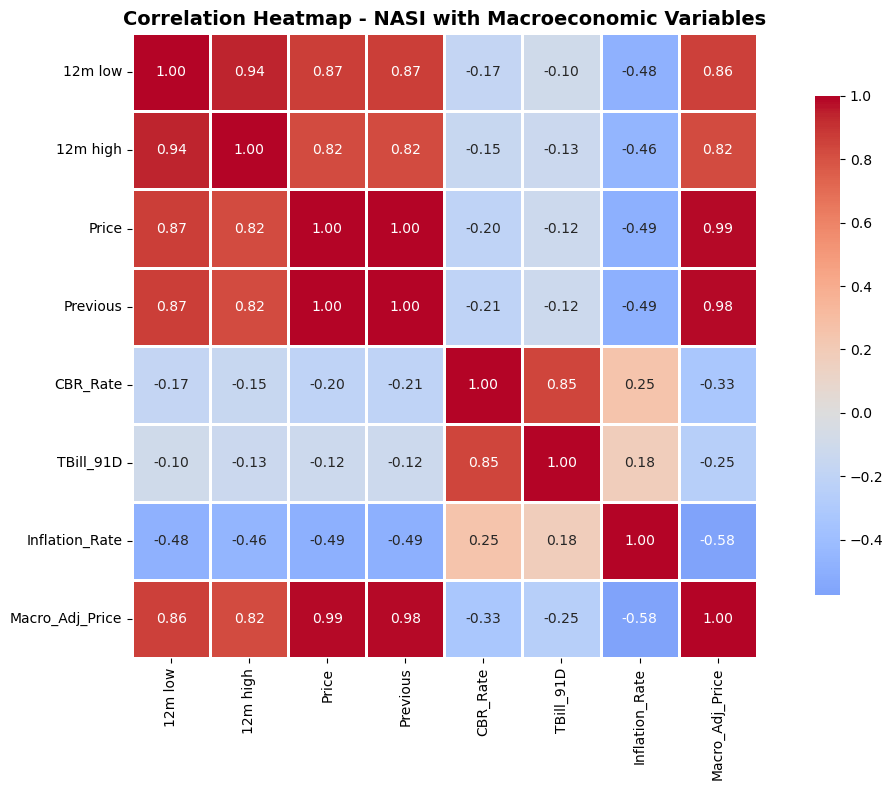

In [21]:
# Create correlation heatmap excluding columns with null values
plt.figure(figsize=(12, 8))

# Select only numeric columns without NaN values
numeric_cols = final_nasi[[col for col in final_nasi.columns if col not in ['Date', 'Code', 'Name']]].apply(pd.to_numeric, errors='coerce')
numeric_cols = numeric_cols.dropna(axis=1, how='any')

# Recalculate correlation matrix for clean columns
corr_clean = numeric_cols.corr()

# Create heatmap
sns.heatmap(corr_clean, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})

plt.title('Correlation Heatmap - NASI with Macroeconomic Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Time series Analysis 

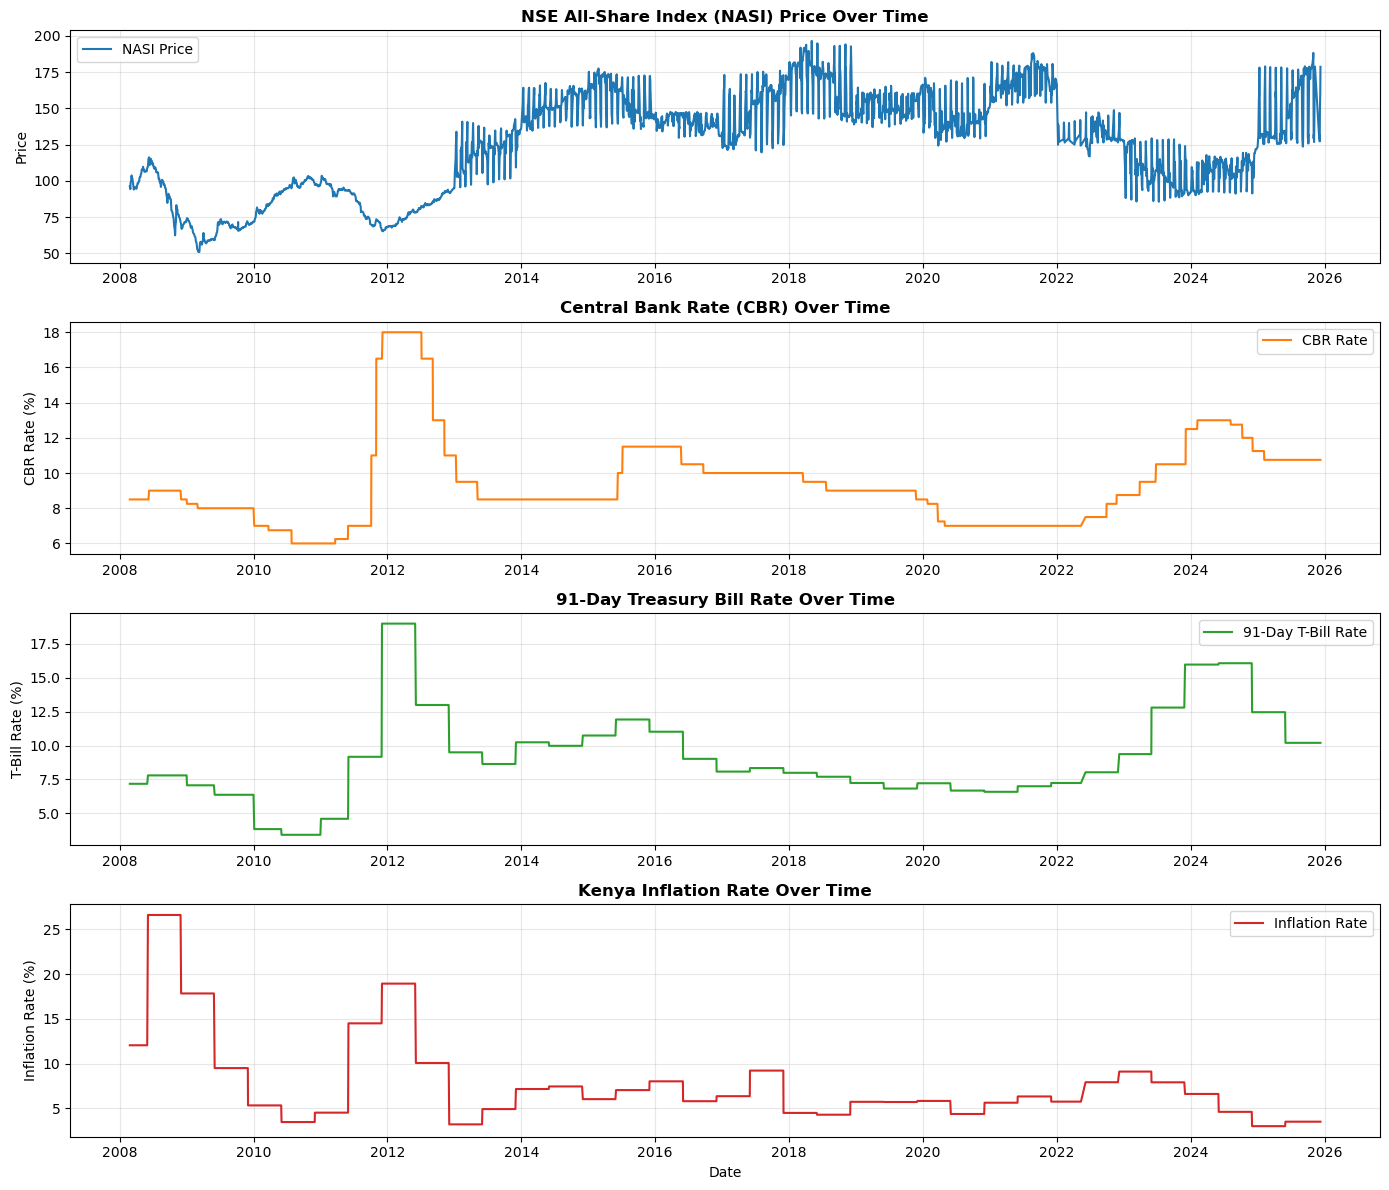

In [22]:
# Create time series plots for NASI and macroeconomic variables
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Plot 1: NASI Price over time
axes[0].plot(final_nasi['Date'], final_nasi['Price'], linewidth=1.5, color='#1f77b4', label='NASI Price')
axes[0].set_title('NSE All-Share Index (NASI) Price Over Time', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: CBR Rate over time
axes[1].plot(final_nasi['Date'], final_nasi['CBR_Rate'], linewidth=1.5, color='#ff7f0e', label='CBR Rate')
axes[1].set_title('Central Bank Rate (CBR) Over Time', fontsize=12, fontweight='bold')
axes[1].set_ylabel('CBR Rate (%)', fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Plot 3: 91-Day T-Bill Rate over time
axes[2].plot(final_nasi['Date'], final_nasi['TBill_91D'], linewidth=1.5, color='#2ca02c', label='91-Day T-Bill Rate')
axes[2].set_title('91-Day Treasury Bill Rate Over Time', fontsize=12, fontweight='bold')
axes[2].set_ylabel('T-Bill Rate (%)', fontsize=10)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

# Plot 4: Inflation Rate over time
axes[3].plot(final_nasi['Date'], final_nasi['Inflation_Rate'], linewidth=1.5, color='#d62728', label='Inflation Rate')
axes[3].set_title('Kenya Inflation Rate Over Time', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Inflation Rate (%)', fontsize=10)
axes[3].set_xlabel('Date', fontsize=10)
axes[3].grid(True, alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.show()

In [23]:
from statsmodels.tsa.stattools import adfuller, kpss

# ── STATIONARITY TESTS ───────────────────────────────────────────────────────

# Select numeric columns for testing
test_columns = ['Price', 'CBR_Rate', 'TBill_91D', 'Inflation_Rate', 'Macro_Adj_Price']

# Create a results summary
stationarity_results = []

for col in test_columns:
    # Remove NaN values for testing
    data = final_nasi[col].dropna()
    
    # ADF Test
    adf_result = adfuller(data, autolag='AIC')
    adf_stat = adf_result[0]
    adf_pvalue = adf_result[1]
    adf_critical = adf_result[4]['5%']
    adf_stationary = 'Yes' if adf_pvalue < 0.05 else 'No'
    
    # KPSS Test
    kpss_result = kpss(data, regression='c', nlags='auto')
    kpss_stat = kpss_result[0]
    kpss_pvalue = kpss_result[1]
    kpss_critical = kpss_result[3]['5%']
    kpss_stationary = 'No' if kpss_pvalue < 0.05 else 'Yes'
    
    stationarity_results.append({
        'Variable': col,
        'ADF_Statistic': adf_stat,
        'ADF_P_Value': adf_pvalue,
        'ADF_Critical_5%': adf_critical,
        'ADF_Stationary': adf_stationary,
        'KPSS_Statistic': kpss_stat,
        'KPSS_P_Value': kpss_pvalue,
        'KPSS_Critical_5%': kpss_critical,
        'KPSS_Stationary': kpss_stationary
    })

stationarity_df = pd.DataFrame(stationarity_results)
stationarity_df

C:\Users\thion\AppData\Local\Temp\ipykernel_17224\2974639434.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(data, regression='c', nlags='auto')
C:\Users\thion\AppData\Local\Temp\ipykernel_17224\2974639434.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(data, regression='c', nlags='auto')
C:\Users\thion\AppData\Local\Temp\ipykernel_17224\2974639434.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(data, regression='c', nlags='auto')
C:\Users\thion\AppData\Local\Temp\ipykernel_17224\2974639434.py:23: InterpolationWarning: The test statistic is outside of t

,Variable,ADF_Statistic,ADF_P_Value,ADF_Critical_5%,ADF_Stationary,KPSS_Statistic,KPSS_P_Value,KPSS_Critical_5%,KPSS_Stationary
0,Price,-1.404793,0.579976,-2.862232,No,4.290845,0.010000,0.463,No
1,CBR_Rate,-2.753324,0.065257,-2.862230,No,0.399430,0.077401,0.463,Yes
2,TBill_91D,-2.306855,0.169767,-2.862227,No,1.206448,0.010000,0.463,No
3,Inflation_Rate,-2.689592,0.075857,-2.862227,No,2.660381,0.010000,0.463,No
4,Macro_Adj_Price,-1.484443,0.541193,-2.862232,No,3.968965,0.010000,0.463,No
